# AgriData Explorer – Python EDA (Final)
This notebook contains all visualizations for the 10 project analysis questions.

In [9]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\\sql\\cleaned_icrisat_agriculture_data.csv")

# Basic check
print("✅ Dataset Shape:", df.shape)
df.head()


✅ Dataset Shape: (16146, 80)


,dist_code,year,state_code,state_name,dist_name,rice_area_(ha),rice_production_(tons),rice_yield_(kg_per_ha),wheat_area_(ha),wheat_production_(tons),...,sugarcane_yield_(kg_per_ha),cotton_area_(ha),cotton_production_(tons),cotton_yield_(kg_per_ha),fruits_area_(ha),vegetables_area_(ha),fruits_and_vegetables_area_(ha),potatoes_area_(ha),onion_area_(ha),fodder_area_(ha)
0,1,1966,14,Chhattisgarh,Durg,548000.0,185000.0,337.59,44000.0,20000.0,...,1777.78,0.0,0.0,58.387468,5950.0,6640.0,12590.0,10.0,600.0,470.0
1,1,1967,14,Chhattisgarh,Durg,547000.0,409000.0,747.71,50000.0,26000.0,...,1500.00,0.0,0.0,58.574607,5770.0,7240.0,13020.0,10.0,560.0,1230.0
2,1,1968,14,Chhattisgarh,Durg,556300.0,468000.0,841.27,53700.0,30000.0,...,1000.00,0.0,0.0,58.762346,5410.0,7400.0,12810.0,100.0,580.0,1020.0
3,1,1969,14,Chhattisgarh,Durg,563400.0,400800.0,711.40,49400.0,26500.0,...,1900.00,0.0,0.0,58.950687,5520.0,7160.0,12690.0,10.0,560.0,840.0
4,1,1970,14,Chhattisgarh,Durg,571600.0,473600.0,828.55,44200.0,29000.0,...,2000.00,0.0,0.0,59.139632,5450.0,7190.0,12640.0,20.0,520.0,420.0


### Question 1

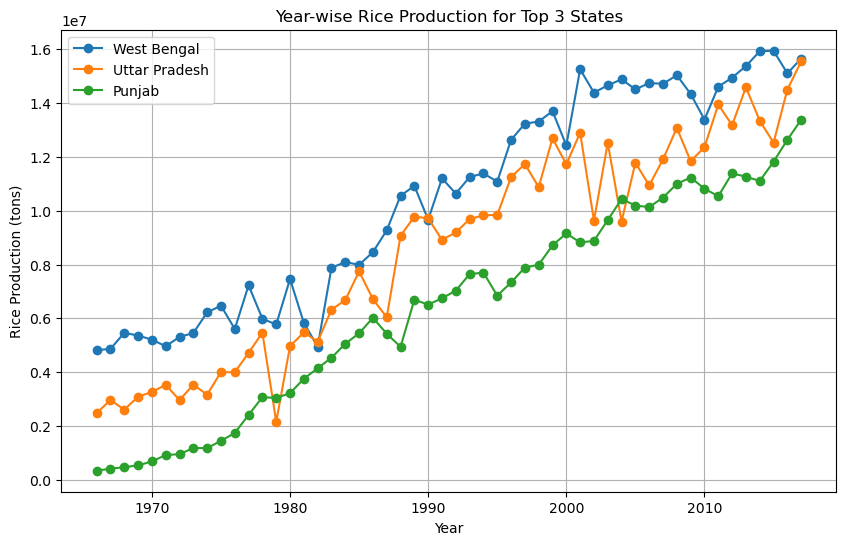

In [11]:
# Code for question 1 visualization
# (Refer to earlier breakdown for full logic)
# ...
top_states = (
    df.groupby('state_name')['rice_production_(tons)']
    .sum()
    .nlargest(3)
    .index
)

plt.figure(figsize=(10,6))
for state in top_states:
    yearly_trend = df[df['state_name'] == state].groupby('year')['rice_production_(tons)'].sum()
    plt.plot(yearly_trend.index, yearly_trend.values, marker='o', label=state)

plt.title("Year-wise Rice Production for Top 3 States")
plt.xlabel("Year")
plt.ylabel("Rice Production (tons)")
plt.legend()
plt.grid(True)
plt.show()


### Question 2

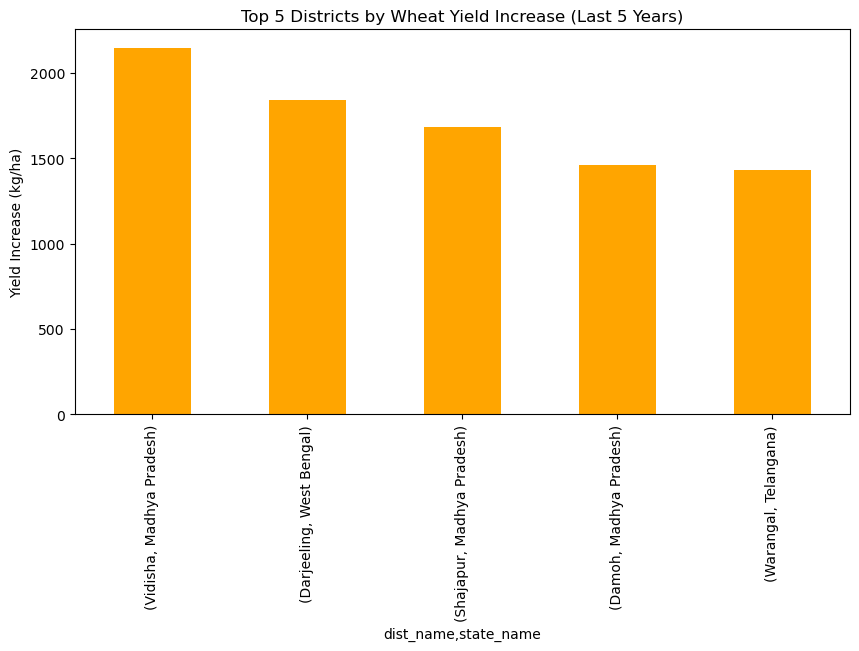

In [13]:
recent_year = df['year'].max()
prev_year = recent_year - 5

df_wheat = df[df['year'].isin([recent_year, prev_year])]
yield_change = df_wheat.pivot_table(index=['dist_name', 'state_name'], 
                                    columns='year', 
                                    values='wheat_yield_(kg_per_ha)').dropna()

yield_change['increase'] = yield_change[recent_year] - yield_change[prev_year]
top_districts = yield_change.sort_values('increase', ascending=False).head(5)

top_districts['increase'].plot(kind='bar', color='orange', figsize=(10, 5))
plt.title("Top 5 Districts by Wheat Yield Increase (Last 5 Years)")
plt.ylabel("Yield Increase (kg/ha)")
plt.show()


### Question 3

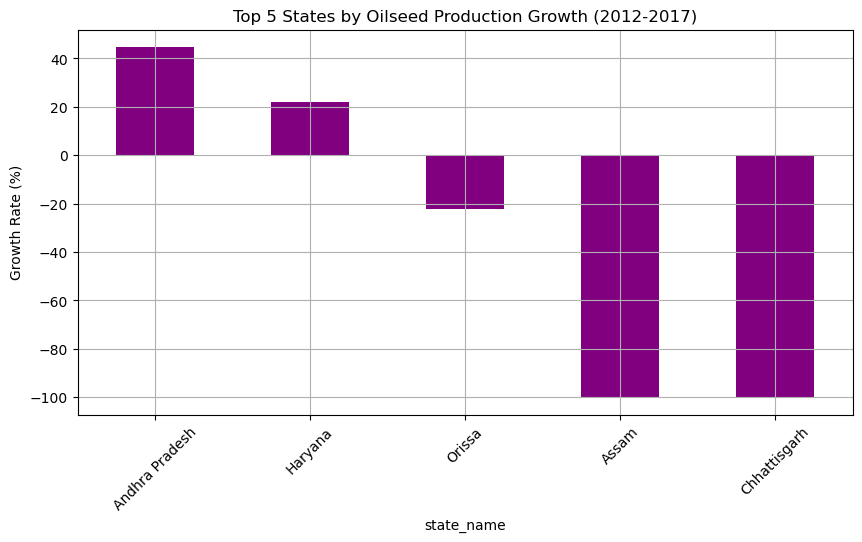

In [15]:
# Code for question 3 visualization
# (Refer to earlier breakdown for full logic)
# ...
recent_year = df['year'].max()
prev_year = recent_year - 5

oilseed_growth = (
    df[df['year'].isin([recent_year, prev_year])]
    .groupby(['state_name', 'year'])['oilseeds_production_(tons)']
    .sum()
    .unstack()
    .dropna()
)

oilseed_growth['growth_rate'] = ((oilseed_growth[recent_year] - oilseed_growth[prev_year]) / oilseed_growth[prev_year]) * 100
top_growth = oilseed_growth.sort_values('growth_rate', ascending=False).head(5)

top_growth['growth_rate'].plot(kind='bar', color='purple', figsize=(10, 5))
plt.title(f"Top 5 States by Oilseed Production Growth ({prev_year}-{recent_year})")
plt.ylabel("Growth Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


### Question 4

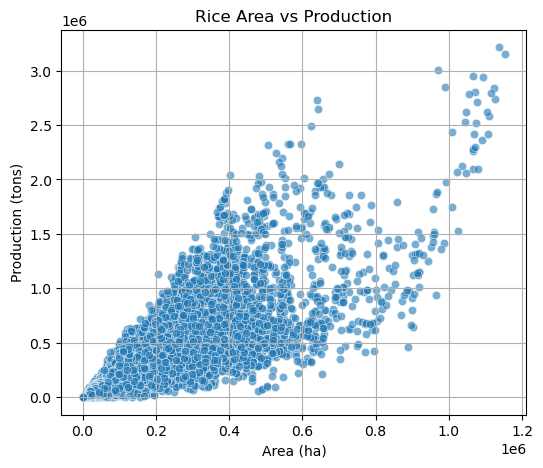

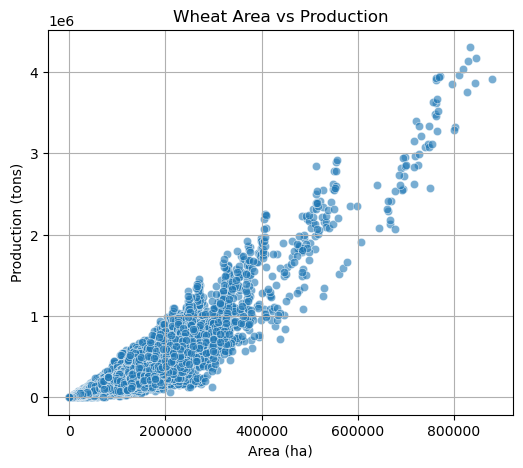

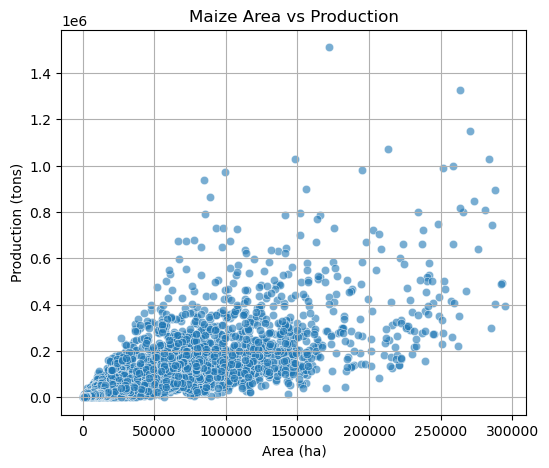

In [17]:
# Code for question 4 visualization
# (Refer to earlier breakdown for full logic)
# ...
crops = ['rice', 'wheat', 'maize']
for crop in crops:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=df,
        x=f"{crop}_area_(ha)",
        y=f"{crop}_production_(tons)",
        alpha=0.6
    )
    plt.title(f"{crop.title()} Area vs Production")
    plt.xlabel("Area (ha)")
    plt.ylabel("Production (tons)")
    plt.grid(True)
    plt.show()


### Question 5

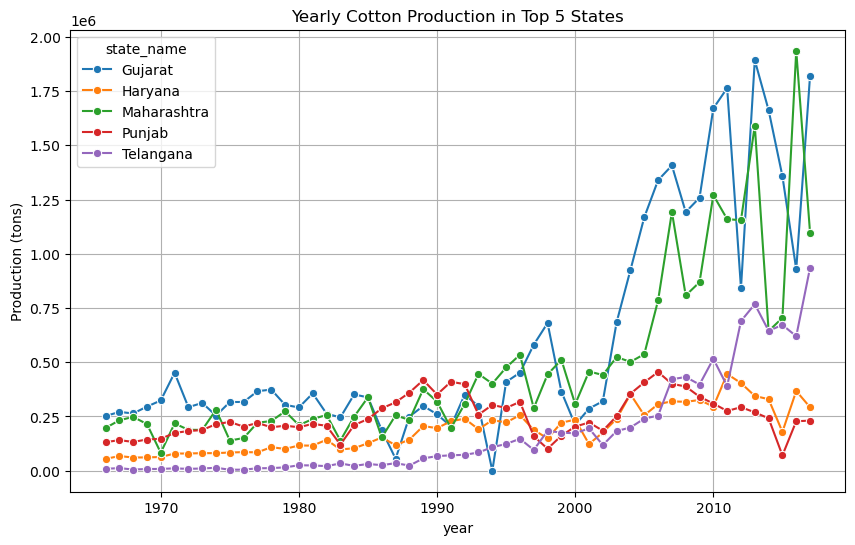

In [19]:
# Code for question 5 visualization
# (Refer to earlier breakdown for full logic)
# ...
top_states = df.groupby('state_name')['cotton_production_(tons)'].sum().nlargest(5).index
cotton_trend = df[df['state_name'].isin(top_states)].groupby(['year', 'state_name'])['cotton_production_(tons)'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=cotton_trend, x='year', y='cotton_production_(tons)', hue='state_name', marker='o')
plt.title("Yearly Cotton Production in Top 5 States")
plt.ylabel("Production (tons)")
plt.grid(True)
plt.show()


### Question 6

In [23]:
# Code for question 6 visualization
# (Refer to earlier breakdown for full logic)
# ...
print("Years in data:", df['year'].unique())



Years in data: [1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979
 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017]


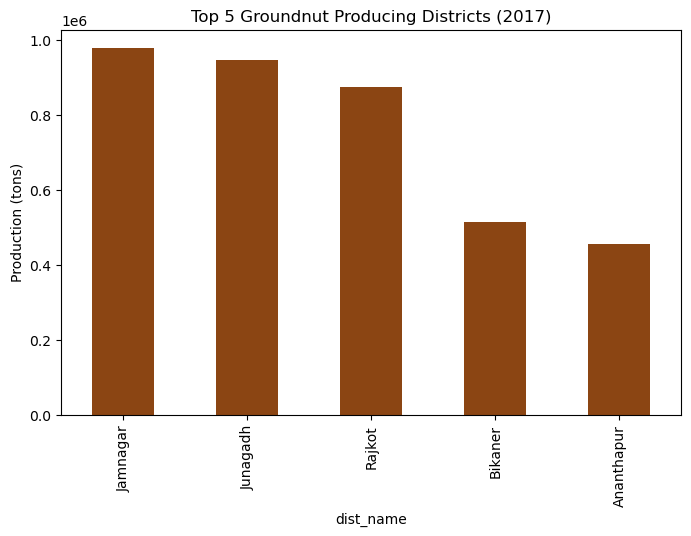

In [25]:
# Safely use the latest year from your data
latest_year = df['year'].max()

# Filter and plot
top_districts = (
    df[df['year'] == latest_year]
    .nlargest(5, 'groundnut_production_(tons)')[['dist_name', 'groundnut_production_(tons)']]
)

top_districts.set_index('dist_name').plot(
    kind='bar', 
    legend=False, 
    figsize=(8,5), 
    color='saddlebrown'
)

plt.title(f"Top 5 Groundnut Producing Districts ({latest_year})")
plt.ylabel("Production (tons)")
plt.show()


### Question 7

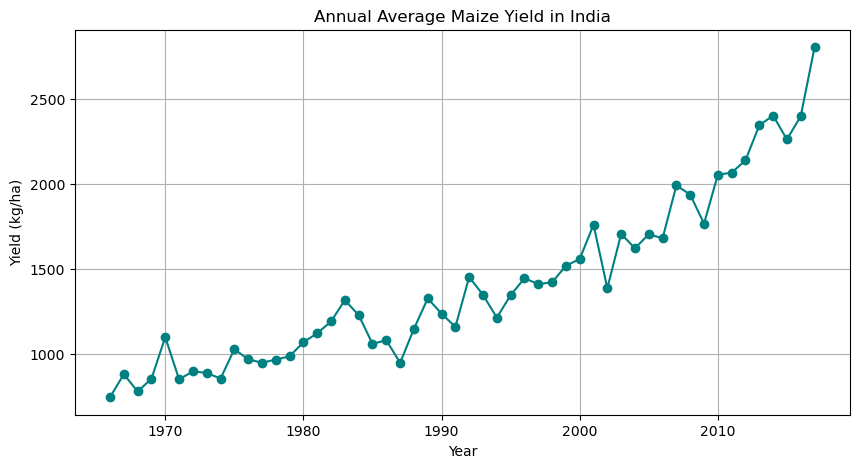

In [27]:
# Code for question 7 visualization
# (Refer to earlier breakdown for full logic)
# ...
plt.figure(figsize=(10, 5))
df.groupby('year')['maize_yield_(kg_per_ha)'].mean().plot(marker='o', color='teal')
plt.title("Annual Average Maize Yield in India")
plt.xlabel("Year")
plt.ylabel("Yield (kg/ha)")
plt.grid(True)
plt.show()


### Question 8

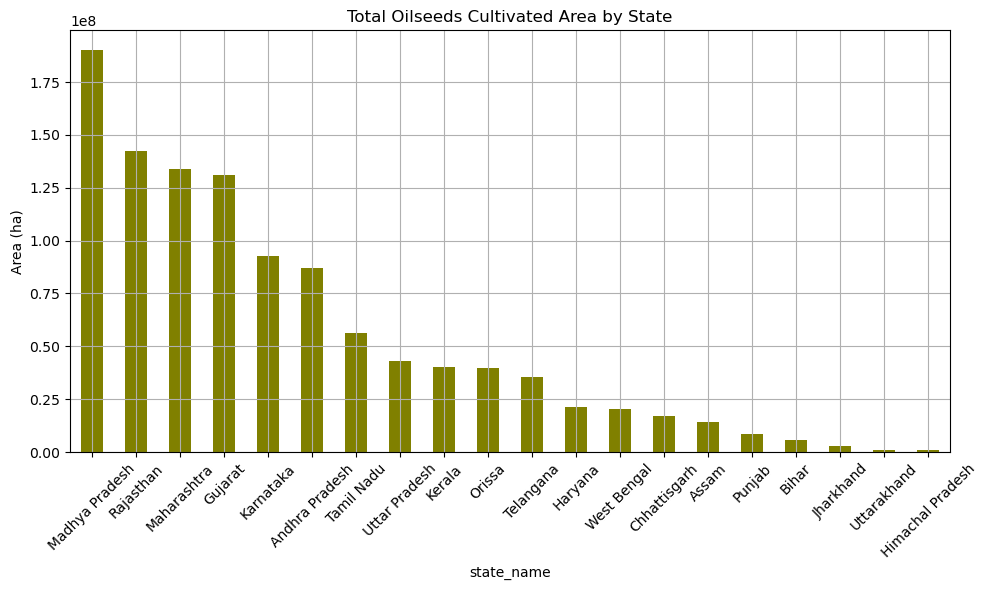

In [29]:
# Code for question 8 visualization
# (Refer to earlier breakdown for full logic)
# ...
total_area = df.groupby('state_name')['oilseeds_area_(ha)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
total_area.plot(kind='bar', color='olive')
plt.title("Total Oilseeds Cultivated Area by State")
plt.ylabel("Area (ha)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### Question 9

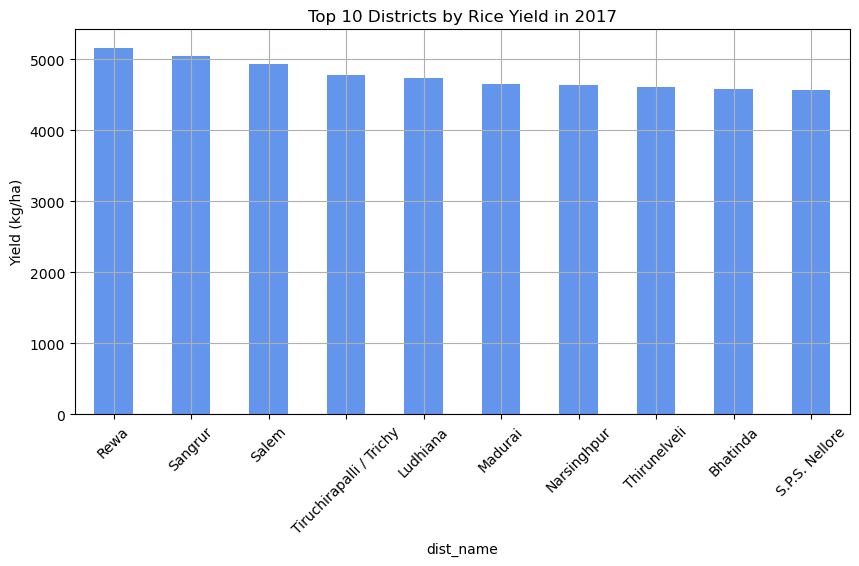

In [31]:
# Code for question 9 visualization
# (Refer to earlier breakdown for full logic)
# ...
latest_year = df['year'].max()
top_districts = df[df['year'] == latest_year].nlargest(10, 'rice_yield_(kg_per_ha)')[['dist_name', 'rice_yield_(kg_per_ha)']]

top_districts.set_index('dist_name').plot(kind='bar', figsize=(10, 5), color='cornflowerblue', legend=False)
plt.title(f"Top 10 Districts by Rice Yield in {latest_year}")
plt.ylabel("Yield (kg/ha)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


### Question 10

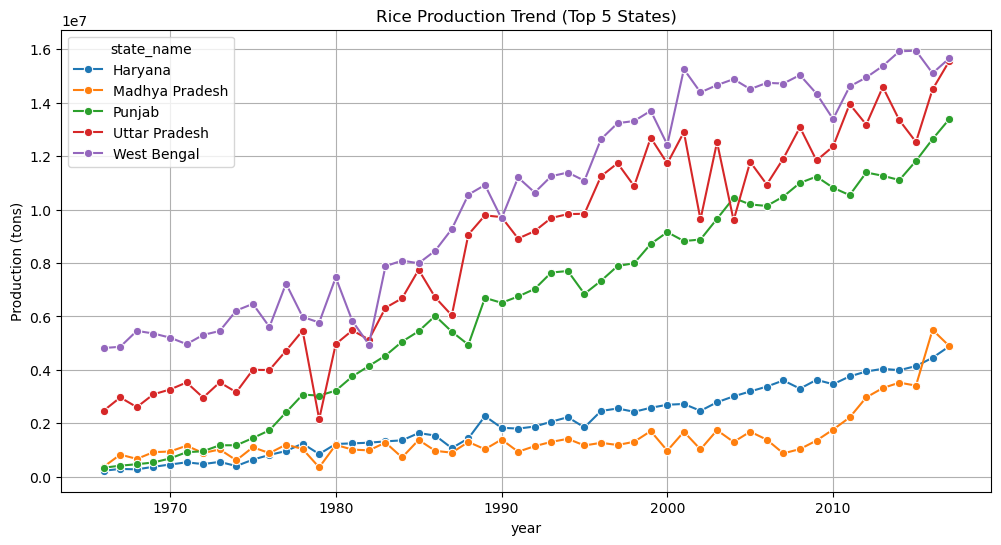

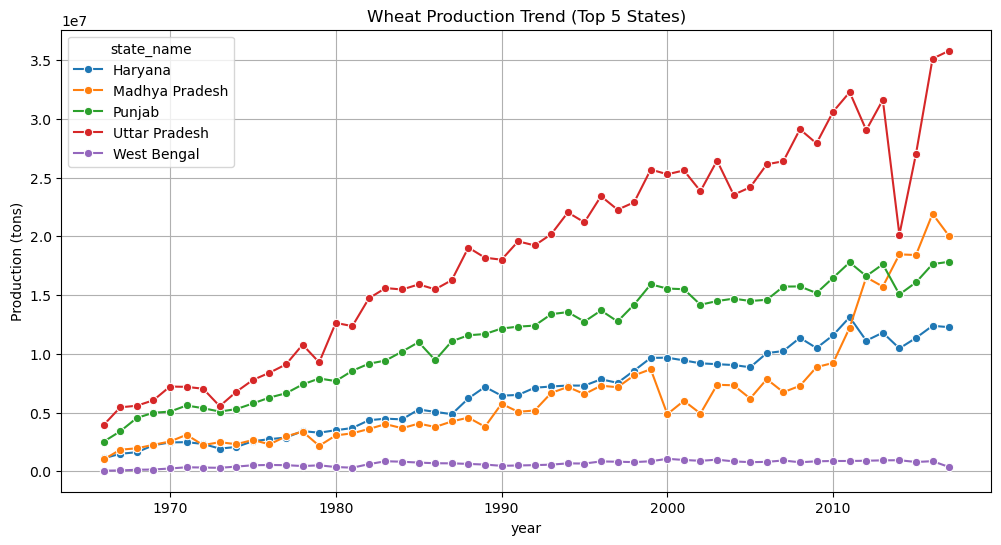

In [33]:
# Code for question 10 visualization
# (Refer to earlier breakdown for full logic)
# ...
top_states = (
    df.groupby('state_name')[['rice_production_(tons)', 'wheat_production_(tons)']]
    .sum()
    .sum(axis=1)
    .nlargest(5)
    .index
)

trend_df = df[df['state_name'].isin(top_states)]
trend_grouped = trend_df.groupby(['year', 'state_name'])[['rice_production_(tons)', 'wheat_production_(tons)']].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_grouped, x='year', y='rice_production_(tons)', hue='state_name', marker='o')
plt.title("Rice Production Trend (Top 5 States)")
plt.ylabel("Production (tons)")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_grouped, x='year', y='wheat_production_(tons)', hue='state_name', marker='o')
plt.title("Wheat Production Trend (Top 5 States)")
plt.ylabel("Production (tons)")
plt.grid(True)
plt.show()
